In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Nous allons installer quelques librairies qui nous permettent d'utiliser l'accélération par GPU pour notre modèle.

In [2]:
!apt-get update -y
!apt-get install -y pciutils lshw
!apt update && apt install -y lsof net-tools

Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:12 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,149 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/main am

En dessous vous retrouver le code necessaire a mettre dans un fichier pour adapter les hyperparametres du modele.

Pour etre sur que le modele a été "pull" correctement nous allons faire un rapide test.

In [3]:
from pathlib import Path
import os, time, math
from openai import OpenAI
from typing import List
from google.colab import files, userdata

In [10]:
model_name   = "gpt-5-mini"   # ← Adapt if needed
TEMPERATURE = 1

In [11]:
OPENAI_API_KEY = userdata.get('OPENAI_API_KEY') or os.getenv("OPENAI_API_KEY")
if not OPENAI_API_KEY:
    raise RuntimeError("Aucune clé OPENAI_API_KEY. Dans Colab: Secrets ▸ ajouter OPENAI_API_KEY.")
client = OpenAI(api_key=OPENAI_API_KEY)

# Sanity check (laisse tes hyperparamètres inchangés ailleurs)
_ = client.chat.completions.create(
    model=model_name,
    messages=[{"role":"system","content":"You are a helpful assistant."},
              {"role":"user","content":"Hello, how are you today?"}],
    temperature=TEMPERATURE
)

print(_)

BadRequestError: Error code: 400 - {'error': {'message': "Unsupported value: 'temperature' does not support 0.1 with this model. Only the default (1) value is supported.", 'type': 'invalid_request_error', 'param': 'temperature', 'code': 'unsupported_value'}}

Avant de commencer nous allons installer l'ensemble des librairies necessaires au fonctionnement de notre code.

In [ ]:
!pip install ocrmypdf PyPDF2 pdf2image pytesseract
!pip install pikepdf
!apt-get update -qq
!apt-get install -y -qq ghostscript tesseract-ocr
!pip install -q ocrmypdf
!pip install PyPDF2 langdetect
!apt-get update -qq
!apt-get install -y -qq unpaper


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.4/163.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 102.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 77.7 MB/s eta 0:00:00
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-droid-fallback.
(Reading database ... 121746 files and directories currently installed.)
Preparing to unpack .../0-fonts-droid-fallback_1%3a6.0.1r16-1.1build1_all.deb ...
Unpacking fonts-droid-fallback (1:6.0.1r16-1.1build1) ...
Selecting previously unselected package poppler-data.
Preparing to

In [ ]:
import os
import re
from PyPDF2 import PdfWriter
from PyPDF2 import PdfReader
import ocrmypdf
import langdetect
from langdetect import detect_langs, LangDetectException
import matplotlib.pyplot as plt
from pathlib import Path
import subprocess
import pandas as pd
import json
import shutil
from tempfile import template
import unicodedata
import pikepdf
import logging
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import textwrap
import logging

**Première étape:** Nous allons prendre le fichier d'avis et nous allons faire un OCR dessus puis le découper en fonction de chaque partie prenante

Nous allons pouvoir commencer notre analyse thématique.
Pour ce faire nous appliquerons un prompt a chaque texte et nous récuperons les réponses dans un fichier Excel.
Ensuite nous prenons l'ensemble de ces thématiques et nous appliquons une nouvelle analyse pour arriver a des grandes thématiques similaires entre acteurs et nous l'indiquons ensuite dans notre excel.

Nous allons faire cela pour chacune des langues nationales presentes dans les avis, a savoir l'italien, l'allemand et le francais. Une fois que cela sera fait nous regrouperons nos thématiques et nous les traduirons toutes en francais

In [ ]:

base_dir     = Path('/content/drive/MyDrive/consu_interest')
roots = {
    "FR": base_dir / "Extracted_French",
    "DE": base_dir / "Extracted_German",
    "IT": base_dir / "Extracted_Italian",
}
output_excel = base_dir / "openai_outputs_with_thematics.xlsx"

# 3) Templates par langue (inchangés)
templates = {
    "FR": {
        "resume": (
            "Tu es un haut-fonctionnaire qui est mandaté pour produire un rapport de résultat "
            "sur un processus de consultation sur"
            " du taux de l’intérêt moratoire. "
            "Veuillez produire un résumé clair et synthétique du document ci-dessous, "
            "en restituant fidèlement les idées principales et la progression argumentative :\n\n"
            "{texte}\n\n"
            "**Réponds** sans en-tête, sans guillemets, sans autre texte."
        ),
        "themes": (
            "Tu es un chercheur en sciences sociales, spécialiste en analyse thématique QUALITATIVE. "
            "À partir du texte fourni ci-dessous, réalise une **analyse thématique interprétative** "
            "en identifiant les **thématiques latentes** (valeurs, préoccupations, représentations) "
            "exprimées par l’acteur dans la procédure de consultation sur la réforme"
            " du taux de l’intérêt moratoire\n\n"
            "Consignes strictes :\n"
            "- Donne uniquement une liste à puces.\n"
            "- Formule chaque thématique de façon concise (2 à 4 mots), au niveau interprétatif "
            "(valeurs/principes), et non contextuel.\n"
            "- Classe-les par ordre décroissant d’importance (poids discursif).\n"
            "- Ne donne ni titre, ni guillemets, ni texte explicatif.\n"
            "Texte à analyser :\n"
            "{texte}\n\n"
            "Thématiques latentes :"
        ),
    },
    "DE": {
        "resume": (
            "Du bist ein hoher Beamter, der beauftragt wurde, einen Ergebnisbericht über ein Konsultationsverfahren zum Verzugszinssatz zu erstellen. "
            "Bitte erstelle eine klare und prägnante Zusammenfassung des folgenden Dokuments, "
            "die die Hauptgedanken und den Argumentationsverlauf originalgetreu wiedergibt:\n\n"
            "{texte}\n\n"
            "**Antworte** ohne Überschrift, ohne Anführungszeichen, ohne weiteren Text."
        ),
        "themes": (
            "Du bist ein Sozialwissenschaftler mit Spezialisierung auf QUALITATIVE thematische Analyse. "
            "Führe aus dem untenstehenden Text eine interpretative thematische Analyse durch, indem du "
            "die latenten Themen (Werte, Anliegen, Repräsentationen) identifizierst, die der Akteur im "
            "Konsultationsverfahren zum Verzugszinssatz äußert.\n\n"
            "Strikte Anweisungen:\n"
            "- Gib ausschließlich eine Aufzählungsliste aus.\n"
            "- Formuliere jedes Thema prägnant (2–4 Wörter) auf interpretativer Ebene (Werte/Prinzipien), nicht kontextuell.\n"
            "- Ordne sie nach absteigendem Gewicht (diskursives Gewicht).\n"
            "- Nutze weder Titel noch Anführungszeichen noch erklärenden Text.\n\n"
            "Zu analysierender Text:\n"
            "{texte}\n\n"
            "Latente Themen:"
        ),
    },
    "IT": {
        "resume": (
            "Sei un alto funzionario incaricato di redigere un rapporto sui risultati di una consultazione sul tasso di interesse moratorio. "
            "Genera un riassunto chiaro e sintetico del seguente documento, "
            "restituendo fedelmente le idee principali e il percorso argomentativo:\n\n"
            "{texte}\n\n"
            "**Rispondi** senza intestazione, senza virgolette, senza altro testo."
        ),
        "themes": (
            "Sei un ricercatore in scienze sociali, specialista in analisi tematica QUALITATIVA. "
            "A partire dal testo fornito di seguito, esegui un'analisi tematica interpretativa identificando "
            "i temi latenti (valori, preoccupazioni, rappresentazioni) espressi dall’attore nella procedura "
            "di consultazione sul tasso di interesse moratorio.\n\n"
            "Istruzioni rigorose:\n"
            "- Fornisci esclusivamente un elenco puntato.\n"
            "- Formula ogni tema in modo conciso (2–4 parole) a livello interpretativo (valori/principi), non contestuale.\n"
            "- Ordinali in ordine decrescente di importanza (peso discorsivo).\n"
            "- Non includere titoli, virgolette o testi esplicativi.\n\n"
            "Testo da analizzare:\n"
            "{texte}\n\n"
            "Temi latenti:"
        ),
    },
}
# -------- MAIN --------
results = []
for lang, folder in roots.items():
    if not folder.exists():
        print(f"⚠️ Folder not found for {lang}: {folder}")
        continue
    tpl = templates[lang]
    for pdf_path in folder.rglob("*.pdf"):
        reader = PdfReader(str(pdf_path))
        full_text = "\n".join(page.extract_text() or "" for page in reader.pages)

        # --- Step 1: summary ---
        prompt_sum = tpl["resume"].format(texte=full_text)
        print("\n=== SUMMARY PROMPT ===\n", prompt_sum)

        try:
            response_sum = client.chat.completions.create(
                model=model_name,
                messages=[{"role": "user", "content": prompt_sum}],
                temperature=TEMPERATURE
            )
            summary = response_sum.choices[0].message.content.strip()
        except Exception as e:
            print(f"⚠️ Summary failed ({lang}) for {pdf_path.name}: {e}")
            summary = ""

        print("=== SUMMARY OUTPUT ===\n", summary)

        # --- Step 2: thematics ---
        prompt_them = tpl["themes"].format(texte=full_text)
        print("\n=== THEMATICS PROMPT ===\n", prompt_them)

        try:
            response_them = client.chat.completions.create(
                model=model_name,
                messages=[{"role": "user", "content": prompt_them}],
                temperature=1
            )
            thematics = response_them.choices[0].message.content.strip()
        except Exception as e:
            print(f"⚠️ Thematics failed ({lang}) for {pdf_path.name}: {e}")
            thematics = ""

        print("=== THEMATICS OUTPUT ===\n", thematics)

        results.append({
            "lang": lang,
            "filename": pdf_path.name,
            "summary": summary,
            "thematics": thematics
        })

df = pd.DataFrame(results)
df.to_excel(output_excel, index=False)
print("✅ Results saved to:", output_excel)
print(df.head())

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
que  le risque  que  de non-initiés  puissent  ne pas connaitre  le taux  d’intérét  moratoire  annuel  reste  raison-
nable.
Il nous  semble  de fait préférable  d’opter  pour  un modéle  de définition  du taux  qui puisse  lui permettre  d’évo-
luer  a travers  les années  afin  d’éviter  une  nouvelle  procédure  parlementaire  dans  quelques  années  pour  un
taux  qui serait  4 nouveau  inadapté.
Cette  tendance  vers  un taux  variable  est €galement  observable  au niveau  de I|’UE  avec  un taux  de base  de
la Banque  centrale  européenne  (BCE)  auquel  est additionné  un pourcentage.  II semble  par ailleurs  que  les
délais  de paiement  se soient  améliorés  depuis.
Par  ailleurs,  cet ajustement  étant  de nature  dispositive,  les parties  restent  toujours  libre  de fixer  un autre
taux  de maniére  contractuelle.
Le Centre  Seilerstrasse  8a T 031 357  33 33
Suisse  Boite  postale  info@die-

Maintenant nous allons traduire les themes des differents avis afin que nous puissons les proceder de maniere unis par la suite

In [ ]:


# 1) Chemins
base_dir     = Path('/content/drive/MyDrive/consu_interest')
input_excel  = base_dir / "openai_outputs_with_thematics.xlsx"
output_excel = base_dir / "openai_outputs_with_thematics.xlsx"

# 2) Charger l’Excel
df = pd.read_excel(input_excel)
print("➡️ Colonnes disponibles :", df.columns.tolist())

# 3) Template de traduction
translate_template = (
    "Veuillez traduire en français la liste de thèmes suivante, "
    "en conservant la structure en liste à puces si présente, "
    "et en veillant à ce que le contenu soit clair et précis :\n\n"
    "{thematics}\n\n"
    "**Réponds** sans en-tête, sans guillemets, sans autre texte."
    "Thèmes en français :"
)


# 4) Translation function
def translate_thematics(text):
    if not text.strip():
        return ""  # nothing to translate

    prompt = translate_template.format(thematics=text)

    # Display the prompt
    print("\n=== PROMPT SENT ===")
    print(prompt)

    try:
        response = client.chat.completions.create(
            model=model_name,
            messages=[{"role": "user", "content": prompt}],
            temperature=TEMPERATURE
        )
        result = response.choices[0].message.content.strip()
        print("=== MODEL RESPONSE ===")
        print(result)
        return result

    except Exception as e:
        print(f"⚠️ Failure for «{text[:30]}…»\n{e}")
        return ""

# 5) Apply the translation
df['thematics_fr'] = df['thematics'].astype(str).apply(translate_thematics)

# 6) Save
df.to_excel(output_excel, index=False)
print("✅ Translated columns added and file saved to:", output_excel)

➡️ Colonnes disponibles : ['lang', 'filename', 'summary', 'thematics']

=== PROMPT SENT ===
Veuillez traduire en français la liste de thèmes suivante, en conservant la structure en liste à puces si présente, et en veillant à ce que le contenu soit clair et précis :

- Indemnisation des créanciers
- Incitation à la ponctualité
- Préservation de l'économie
- Prévisibilité juridique
- Simplicité administrative
- Prudence réglementaire
- Proportionnalité des sanctions

**Réponds** sans en-tête, sans guillemets, sans autre texte.Thèmes en français :
=== MODEL RESPONSE ===
- Indemnisation des créanciers
- Incitation à la ponctualité
- Préservation de l'économie
- Prévisibilité juridique
- Simplicité administrative
- Prudence réglementaire
- Proportionnalité des sanctions

=== PROMPT SENT ===
Veuillez traduire en français la liste de thèmes suivante, en conservant la structure en liste à puces si présente, et en veillant à ce que le contenu soit clair et précis :

- Compensation intégrale du 

In [ ]:

# 1) Chemins & paramètres
base_dir    = Path('/content/drive/MyDrive/consu_interest')
input_file  = base_dir / "openai_outputs_with_thematics.xlsx"
col_name    = "thematics_fr"

# 2) Charger le DataFrame
df = pd.read_excel(input_file)

# 3) Construire et afficher le prompt
texts    = df[col_name].dropna().astype(str).tolist()
numbered = "\n".join(f"{i+1}. {t}" for i,t in enumerate(texts,1))
prompt   = f"""\
Tu es un chercheur en sciences sociales, spécialiste en analyse thématique qualitative.
Voici la liste complète des thématique extraits de la colonne « {col_name} » :
{numbered}

Effectue un regroupement en exactement 5 catégories thématiques représentatives et distinguables.
**Réponds** sans en-tête, sans guillemets, sous la forme :
<catégorie> : description de la catégorie
"""
print("=== PROMPT ENVOYÉ ===\n", prompt)

#call chatgpt
try:
    response_obj = client.chat.completions.create(
        model=model_name,
        messages=[{"role": "user", "content": prompt}],
        temperature=TEMPERATURE
    )
    response = response_obj.choices[0].message.content.strip()

except Exception as e:
    raise RuntimeError(f"OpenAI API error:\n{e}")

print("=== MODEL RESPONSE ===\n", response)

# 5) Delete the old column if it exists
if 'general_theme_codebook' in df.columns:
    df = df.drop(columns=['general_theme_codebook'])

# 6) Insert the new column just after 'thematics_fr'
insert_at = df.columns.get_loc(col_name) + 1
df.insert(insert_at, 'general_theme_codebook', "")

# 7) Place the model's response in the first cell below the header
df.iat[0, insert_at] = response

# 8) Save
df.to_excel(input_file, index=False)
print("✅ Column 'general_theme_codebook' added, response inserted in row 1.")

=== PROMPT ENVOYÉ ===
 Tu es un chercheur en sciences sociales, spécialiste en analyse thématique qualitative.
Voici la liste complète des thématique extraits de la colonne « thematics_fr » :
2. - Indemnisation des créanciers
- Incitation à la ponctualité
- Préservation de l'économie
- Prévisibilité juridique
- Simplicité administrative
- Prudence réglementaire
- Proportionnalité des sanctions
3. - Compensation intégrale du préjudice
- Protection des liquidités des entreprises
- Taux minimum adéquat
- Alignement sur le marché
- Ajustement administratif annuel
- Prévisibilité juridique
- Dissuasion des retards de paiement
- Respect des mécanismes légaux
4. - Prévention du surendettement
- Clarté des règles
- Protection des débiteurs vulnérables
- Proportionnalité des sanctions
- Prévisibilité et stabilité
- Indemnisation équitable des créanciers
- Prudence au regard du contexte économique
- Simplicité administrative
- Responsabilité publique en matière d'intervention
5. - Sécurité jurid

On sépare les thematiques de leurs descriptions dans une nouvelle colonne

In [ ]:

def extract_themes(cell):
    # On transforme en chaîne et on découpe sur tout type de saut de ligne
    lines = re.split(r'[\r\n]+', str(cell))
    themes = []
    for line in lines:
        line = line.strip()
        if not line:
            continue
        if ':' in line:
            theme, _ = line.split(':', 1)
            themes.append(theme.strip())
        else:
            # Cas où il n’y a pas de “:”
            themes.append(line)
    return themes

# 3) Appliquer et créer une colonne de listes
df['general_theme_fr'] = df['general_theme_codebook'].apply(extract_themes)
df["general_theme_fr"] = df["general_theme_fr"].apply(lambda lst: "\n".join(lst))

# 4) Save back to Excel
df.to_excel(input_file, index=False)

Pour éviter tout probleme d'hallucination de notre modele nous rajoutons la catégorie neutre dans notre cellule de thématiques générales.

In [ ]:
ancienne_valeur = df.at[0, "general_theme_codebook"]
if pd.isna(ancienne_valeur):
    ancienne_valeur = ""


df.at[0, "general_theme_fr"] = f"{ancienne_valeur} \\nAucun de ces thèmes: le document ne correspond a aucun des autres thèmes mentionnés"

# 4. Sauvegarder dans un nouveau fichier (ou écraser l’existant)
df.to_excel(input_file, index=False)

Pour traduire les themes generaux en allemand et italien pour pouvoir apres les appliquer sur les textes

In [ ]:

col_name = "general_theme_fr"

# 2) Charger l’Excel
df = pd.read_excel(input_excel)

# 3) Template de traduction
translate_template = (
    "Bitte übersetzen Sie die folgende Themenliste ins Deutsche, "
    "unter Beibehaltung der Aufzählungsstruktur, falls vorhanden, "
    "und achten Sie darauf, dass der Inhalt klar und präzise ist:\n\n"
    "{thematics}\n\n"
    "**beantworte** ohne Überschrift, ohne Anführungszeichen, ohne weiteren Text. "
    "Themen auf Deutsch:"
)

# 4) Fonction de traduction
def translate_thematics(general_theme_fr):
    if not general_theme_fr.strip():
        return ""

    prompt = translate_template.format(thematics=general_theme_fr)
    print("\n=== PROMPT ENVOYÉ ===")
    print(prompt)

    # --- REPLACEMENT OF OLLAMA CALL ---
    try:
        response_obj = client.chat.completions.create(
            model=model_name,
            messages=[{"role": "user", "content": prompt}],
            temperature=TEMPERATURE
        )
        response = response_obj.choices[0].message.content.strip()

    except Exception as e:
        print(f"⚠️ Échec pour «{general_theme_fr[:30]}…» : {e}")
        return ""
    # ----------------------------------

    print("=== RÉPONSE DU MODÈLE ===")
    print(response)
    return response


translated = df[col_name].fillna("").astype(str).apply(translate_thematics)

if 'general_theme_de' in df.columns:
    df = df.drop(columns=['general_theme_de'])

insert_at = df.columns.get_loc(col_name) + 1
df.insert(insert_at, 'general_theme_de', translated)

df.to_excel(output_excel, index=False)
print(f"✅ Colonne 'general_theme_de' ajoutée, réponses enregistrées dans {output_excel}")



=== PROMPT ENVOYÉ ===
Bitte übersetzen Sie die folgende Themenliste ins Deutsche, unter Beibehaltung der Aufzählungsstruktur, falls vorhanden, und achten Sie darauf, dass der Inhalt klar und präzise ist:

Sécurité juridique et stabilité : valorisation de la prévisibilité, de la continuité normative et de la stabilité économique et procédurale (sécurité du droit, maintien du statu quo, stabilité normative, respect de la jurisprudence, résistance au changement) afin de permettre planification et confiance pour acteurs publics et privés.

Protection des créanciers et incitations au paiement : priorité à l’indemnisation adéquate et à la préservation de la liquidité des créanciers (compensation intégrale, couverture des coûts de refinancement, maintien de la discipline des paiements, effet dissuasif), tout en cherchant à prévenir l’enrichissement indû de l’État et à garantir l’égalité de traitement des créanciers.

Alignement sur le marché et adaptabilité prudente : promotion d’un ajusteme

In [ ]:

col_name = "general_theme_fr"

# 3) Template de traduction
translate_template = (
    "Traduci il seguente elenco di temi in italiano, "
    "mantenendo la struttura dell'elenco puntato, se presente, "
    "e assicurandoti che il contenuto sia chiaro e preciso:\n\n"
    "{thematics}\n\n"
    "**rispondi** senza titoli, senza virgolette, senza altro testo aggiuntivo. "
    "Temi in italiano:"
)

def translate_thematics(general_theme_fr):
    if not general_theme_fr.strip():
        return ""

    prompt = translate_template.format(thematics=general_theme_fr)
    print("\n=== PROMPT ENVOYÉ ===")
    print(prompt)

    # --- REPLACE OLLAMA BY OPENAI CHAT COMPLETIONS ---
    try:
        response_obj = client.chat.completions.create(
            model=model_name,
            messages=[{"role": "user", "content": prompt}],
            temperature=TEMPERATURE   # <-- uses your global setting
        )
        response = response_obj.choices[0].message.content.strip()

    except Exception as e:
        print(f"⚠️ Échec pour «{general_theme_fr[:30]}…» : {e}")
        return ""
    # -------------------------------------------------

    print("=== RÉPONSE DU MODÈLE ===")
    print(response)
    return response

translated = df[col_name].fillna("").astype(str).apply(translate_thematics)

if 'general_theme_it' in df.columns:
    df = df.drop(columns=['general_theme_it'])
insert_at = df.columns.get_loc(col_name) + 1
df.insert(insert_at, 'general_theme_it', translated)

df.to_excel(output_excel, index=False)
print(f"✅ Colonne 'general_theme_it' ajoutée, réponses enregistrées dans {output_excel}")



=== PROMPT ENVOYÉ ===
Traduci il seguente elenco di temi in italiano, mantenendo la struttura dell'elenco puntato, se presente, e assicurandoti che il contenuto sia chiaro e preciso:

Sécurité juridique et stabilité : valorisation de la prévisibilité, de la continuité normative et de la stabilité économique et procédurale (sécurité du droit, maintien du statu quo, stabilité normative, respect de la jurisprudence, résistance au changement) afin de permettre planification et confiance pour acteurs publics et privés.

Protection des créanciers et incitations au paiement : priorité à l’indemnisation adéquate et à la préservation de la liquidité des créanciers (compensation intégrale, couverture des coûts de refinancement, maintien de la discipline des paiements, effet dissuasif), tout en cherchant à prévenir l’enrichissement indû de l’État et à garantir l’égalité de traitement des créanciers.

Alignement sur le marché et adaptabilité prudente : promotion d’un ajustement des taux et des ré

In [ ]:

# 1) Chemins & paramètres
base_dir = Path('/content/drive/MyDrive/consu_interest')
input_excel = base_dir / "openai_outputs_with_thematics.xlsx"
# On réécrit dans le même fichier
output_excel = input_excel
roots = {
    "FR": base_dir / "Extracted_French",
    "DE": base_dir / "Extracted_German",
    "IT": base_dir / "Extracted_Italian",
}

# 2) Charger la liste des thèmes généraux
# (utile pour le prompt)
df = pd.read_excel(input_excel)
general_themes = {}
for lang in ["FR", "DE", "IT"]:
    col = f"general_theme_{lang.lower()}"
    if col not in df.columns:
        raise KeyError(f"Colonne manquante dans Excel: {col}")
    themes = df[col].dropna().unique().tolist()
    general_themes[lang] = ", ".join(themes)

# 3) Templates par langue
prompt_template = {
    "FR": (
        "Tu es un chercheur en sciences sociales, spécialiste en analyse thématique qualitative.\n"
        "Pour chaque document, indique **uniquement** le thème général correspondant.\n\n"
        "Texte à analyser:\n{texte}\n\n"
        "Thèmes généraux possibles : {general}\n\n"
        "Réponds **exactement** par la seule catégorie choisie (pas de CSV, pas de JSON)."
    ),
    "DE": (
        "Du bist ein Sozialwissenschaftler mit Spezialisierung auf qualitative thematische Analyse.\n"
        "Gib für jedes Dokument **ausschließlich** das zutreffende allgemeine Thema an.\n\n"
        "Zu analysierender Text:\n{texte}\n\n"
        "Mögliche allgemeine Themen : {general}\n\n"
        "Antworte **exakt** mit der ausgewählten Kategorie (kein CSV, kein JSON)."
    ),
    "IT": (
        "Sei un ricercatore in scienze sociali, specialista nell'analisi tematica qualitativa.\n"
        "Per ogni documento, indica **esclusivamente** il tema generale corrispondente.\n\n"
        "Testo da analizzare:\n{texte}\n\n"
        "Possibili temi generali  : {general}\n\n"
        "Rispondi **esattamente** indicando solo la categoria scelta (no CSV, no JSON)."
    )
}

def categorize_document(full_text: str, template: str, general_list: str) -> str:
    prompt = template.format(texte=full_text, general=general_list)
    print("\n=== PROMPT ENVOYÉ ===")
    print(prompt)

    # --- OPENAI CALL (replaces ollama) ---
    try:
        response_obj = client.chat.completions.create(
            model=model_name,
            messages=[{"role": "user", "content": prompt}],
            temperature=TEMPERATURE     # <-- global temperature
        )
        response = response_obj.choices[0].message.content.strip()

    except Exception as e:
        print(f"⚠️ Erreur : {e}")
        return ""
    # -------------------------------------

    print("=== RÉPONSE DU MODÈLE ===")
    print(response)

    return response.splitlines()[0] if response else ""

categories = []
files = []
langs = []
for lang, folder in roots.items():
    if not folder.exists():
        continue
    template = prompt_template[lang]
    general_list = general_themes[lang]
    for pdf_path in folder.rglob("*.pdf"):
        reader = PdfReader(str(pdf_path))
        full_text = "\n".join(page.extract_text() or "" for page in reader.pages)
        category = categorize_document(full_text, template, general_list)
        files.append(pdf_path.name)
        langs.append(lang)
        categories.append(category)
df['general_category'] = pd.Series(categories, index=df.index[:len(categories)])

df.to_excel(output_excel, index=False)
print(f"✅ Colonnes ajoutées et mis à jour dans : {output_excel}")



=== PROMPT ENVOYÉ ===
Tu es un chercheur en sciences sociales, spécialiste en analyse thématique qualitative.
Pour chaque document, indique **uniquement** le thème général correspondant.

Texte à analyser:
Conseil  d’Etat  CE
Staatsrat  SR
Rue  des  Chanoines  17, 1701  Fribourg
ETAT  DE FRIBOURG
STAAT  FREIBURG  T +41  26 305  10 40, F +41  26 305  10 48
www.fr.ch/ce
Conseil  d Etat
Rue  des  Chanoines  17, 1701  Fribourg
PAR  COURRIEL
Conseil  national
Commission  des affaires  juridiques
Monsieur  Vincent  Maitre
Vice-Président
3003  Berne
Courriel  : zz@bj.admin.ch
Fribourg,  le 4 octobre  2022
2022-1018
16.470  lv. parl.  Regazzi.  Aligner  l’intérét  moratoire  appliqué  par  la Confédération  sur
les taux  du marché  — Procédure  de consultation
Monsieur  le Vice-Président,
Nous  vous  remercions  de nous  avoir  associés  a la consultation  sur |’ objet  précité.  La proposition  de
la Commission  des affaires  juridiques  du Conseil  National  concernant  la révision  de I’ar

In [ ]:

# 2) Charger le DataFrame
df = pd.read_excel(input_excel)
print("➡️ Colonnes disponibles :", df.columns.tolist())

# 3) Template de traduction
translate_template = (
    "Veuillez traduire en français le thème suivant"
    ":\n\n"
    "{category}\n\n"
    "**Réponds** sans en-tête, sans guillemets, sans autre texte. "
    "Thème en français :"
)

def translate_category(category: str) -> str:
    if not category.strip():
        return ""

    prompt = translate_template.format(category=category)
    print("\n=== PROMPT ENVOYÉ ===")
    print(prompt)

    # --- REPLACE OLLAMA WITH OPENAI CHAT COMPLETIONS ---
    try:
        response_obj = client.chat.completions.create(
            model=model_name,
            messages=[{"role": "user", "content": prompt}],
            temperature=TEMPERATURE      # ← global variable
        )
        response = response_obj.choices[0].message.content.strip()

    except Exception as e:
        print(f"⚠️ Échec pour «{category[:30]}…» : {e}")
        return ""
    # ---------------------------------------------------

    print("=== RÉPONSE DU MODÈLE ===")
    print(response)
    return response

df['category_fr'] = df['general_category'].fillna("").astype(str).apply(translate_category)

df.to_excel(output_excel, index=False)
print(f"✅ Traductions enregistrées dans : {output_excel}")


➡️ Colonnes disponibles : ['lang', 'filename', 'summary', 'thematics', 'thematics_fr', 'general_theme_codebook', 'general_theme_fr', 'general_theme_it', 'general_theme_de', 'general_category']

=== PROMPT ENVOYÉ ===
Veuillez traduire en français le thème suivant:

Protection des créanciers et incitations au paiement

**Réponds** sans en-tête, sans guillemets, sans autre texte. Thème en français :
=== RÉPONSE DU MODÈLE ===
Protection des créanciers et mécanismes d'incitation au paiement

=== PROMPT ENVOYÉ ===
Veuillez traduire en français le thème suivant:

Protection des créanciers et incitations au paiement

**Réponds** sans en-tête, sans guillemets, sans autre texte. Thème en français :
=== RÉPONSE DU MODÈLE ===
Protection des créanciers et incitations au paiement

=== PROMPT ENVOYÉ ===
Veuillez traduire en français le thème suivant:

Équité, proportionnalité et protection des débiteurs et de l’intérêt public

**Réponds** sans en-tête, sans guillemets, sans autre texte. Thème en fran

Dans le cas ou on fait usage d'un modèle agentique (comme Qwen3) , il est necessaire que nous supprimions l'ensemble de la phase de raisonnement du modèle présent dans ces réponses

On sépare les thematiques de leurs descriptions dans une nouvelle colonne

In [ ]:

def extract_themes(cell):
    # On transforme en chaîne et on découpe sur tout type de saut de ligne
    lines = re.split(r'[\r\n]+', str(cell))
    themes = []
    for line in lines:
        line = line.strip()
        if not line:
            continue
        if ':' in line:
            theme, _ = line.split(':', 1)
            themes.append(theme.strip())
        else:
            # Cas où il n’y a pas de “:”
            themes.append(line)
    return themes

# 3) Appliquer et créer une colonne de listes
df['general_theme_fr'] = df['general_theme_codebook'].apply(extract_themes)
df["general_theme_fr"] = df["general_theme_fr"].apply(lambda lst: "\n".join(lst))

# 4) Save back to Excel
df.to_excel(input_file, index=False)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/341 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/114 [00:00<?, ?B/s]

2_Dense/model.safetensors:   0%|          | 0.00/1.58M [00:00<?, ?B/s]

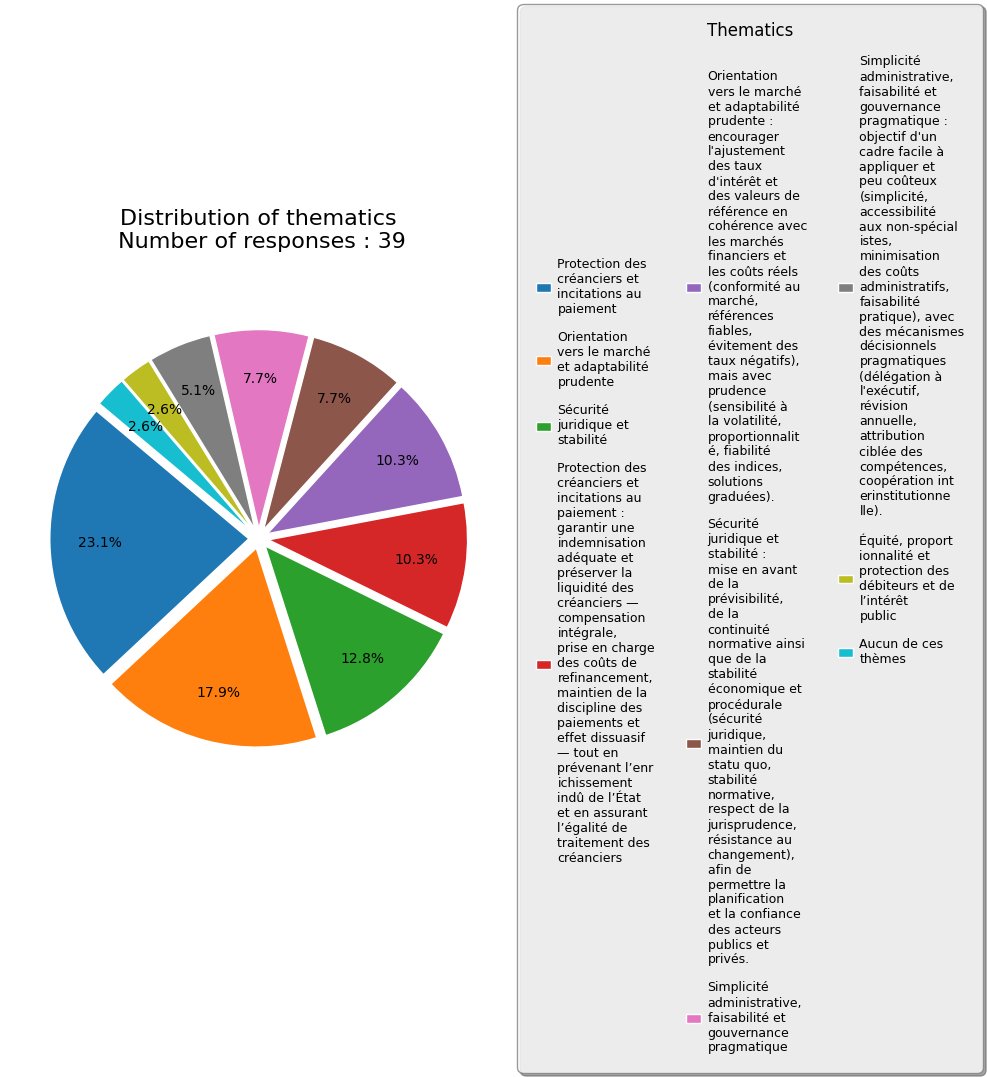

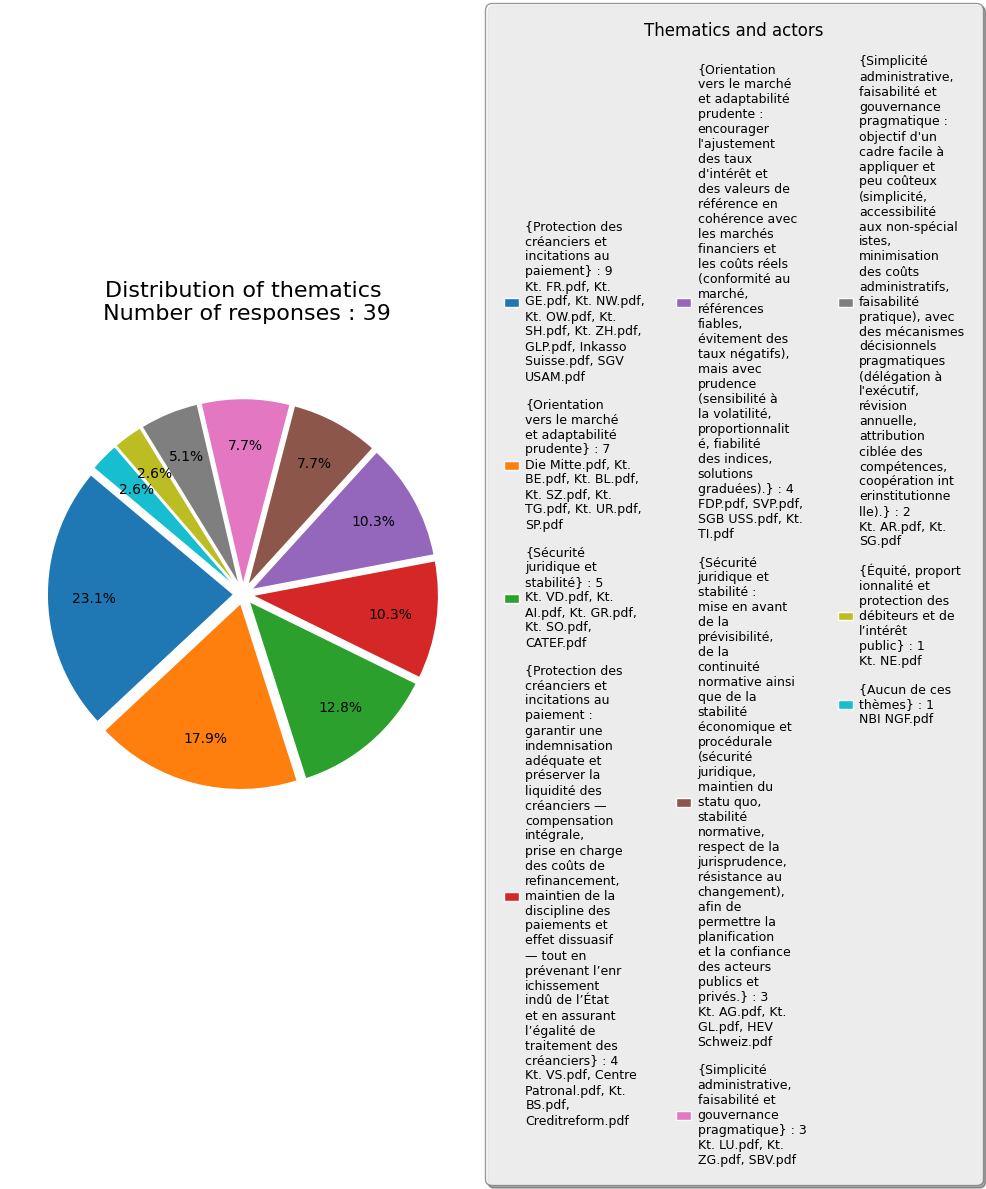

✅ Graphique enregistré dans : ./graphs/distribution_cleaned_themes_actors.pdf


In [ ]:


theme_col = 'category_fr'

df = df.dropna(subset=[theme_col])
themes = df[theme_col].tolist()

# 2. Compute embeddings using a pretrained model
# Choice of embedding model: " sentence-transformers/distiluse-base-multilingual-cased-v1" For working with French
model = SentenceTransformer('distiluse-base-multilingual-cased-v1')
theme_embeddings = model.encode(themes)

# 3. Calculate pairwise cosine similarity
similarity_matrix = cosine_similarity(theme_embeddings)

# Set diagonal to 0 to ignore self-similarity
np.fill_diagonal(similarity_matrix, 0)

# 4. Merge themes based on similarity threshold (0.95 - 0.99)
similarity_threshold_low = 0.80
similarity_threshold_high = 0.9999

# Create a mapping for merged themes
theme_map = dict()

for idx, theme in enumerate(themes):
    if theme in theme_map:
        continue

    # Find indices where similarity is within threshold
    similar_idxs = np.where(
        (similarity_matrix[idx] >= similarity_threshold_low) &
        (similarity_matrix[idx] <= similarity_threshold_high)
    )[0]

    # Merge themes into the most frequent canonical theme
    candidates = [themes[i] for i in similar_idxs] + [theme]
    canonical = df[df[theme_col].isin(candidates)][theme_col].value_counts().idxmax()

    for candidate in candidates:
        theme_map[candidate] = canonical

# Apply merging
df['cleaned_theme'] = df[theme_col].map(theme_map)

# 5. Recount theme frequencies after cleaning
cleaned_counts = df['cleaned_theme'].value_counts()

# --- Graph Styling (Themes Only) ---
fig, ax = plt.subplots(figsize=(10, 10))
explode = [0.05] * len(cleaned_counts)

wedges, texts, autotexts = ax.pie(
    cleaned_counts,
    autopct='%1.1f%%',
    startangle=140,
    explode=explode,
    pctdistance=0.75,
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
)

ax.set(aspect="equal")
ax.set_title(
    f"Distribution of thematics\n Number of responses : {cleaned_counts.sum()}",
    fontsize=16,
    pad=30
)

legend_labels = ["\n".join(textwrap.wrap(cat, width=15)) for cat in cleaned_counts.index]

legend = ax.legend(
    wedges,
    legend_labels,
    title="Thematics",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9,
    title_fontsize=12,
    ncol=3,
    frameon=True,
    shadow=True,
    facecolor='white',
    framealpha=0.8,
    edgecolor='gray',
    borderpad=1,
    handlelength=1.2,
    handletextpad=0.5,
    columnspacing=2.5,
    labelspacing=1.2
)
legend.get_frame().set_boxstyle('round,pad=0.5')

plt.tight_layout()
plt.show()

# --- Second Graph (Themes with Actors) ---
actors_by_cat = df.groupby('cleaned_theme')['filename'].apply(list)

fig, ax = plt.subplots(figsize=(10, 10))

wedges, texts, autotexts = ax.pie(
    cleaned_counts,
    autopct='%1.1f%%',
    startangle=140,
    explode=explode,
    pctdistance=0.75,
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
)

ax.set(aspect="equal")
ax.set_title(
    f"Distribution of thematics\n Number of responses : {cleaned_counts.sum()}",
    fontsize=16,
    pad=30
)

def wrap_label(cat):
    cat_wrapped = "\n".join(textwrap.wrap(cat, width=15))
    acteurs = actors_by_cat.get(cat, [])
    details_wrapped = "\n".join(textwrap.wrap(", ".join(acteurs), width=20))
    label = rf"{{{cat_wrapped}}} : {len(acteurs)}"
    if acteurs:
        label += "\n" + details_wrapped
    return label

legend_labels = [wrap_label(cat) for cat in cleaned_counts.index]

legend = ax.legend(
    wedges,
    legend_labels,
    title="Thematics and actors",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9,
    title_fontsize=12,
    ncol=3,
    frameon=True,
    shadow=True,
    facecolor='white',
    framealpha=0.8,
    edgecolor='gray',
    borderpad=1,
    handlelength=1.2,
    handletextpad=0.5,
    columnspacing=2.5,
    labelspacing=1.2
)
legend.get_frame().set_boxstyle('round,pad=0.5')

plt.tight_layout()
plt.show()

# Save the figure
output_dir = './graphs'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "distribution_cleaned_themes_actors.pdf")
fig.savefig(output_path, bbox_inches="tight")
plt.close()

print(f"✅ Graphique enregistré dans : {output_path}")



In [ ]:

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)
logger = logging.getLogger(__name__)


output_excel = base_dir / "openai_outputs_with_thematics.xlsx"

# --- Indexation des fichiers PDF ---
file_map = {}
for lang, folder in roots.items():
    if not folder.exists():
        logger.warning(f"Dossier non trouvé: {folder}")
        file_map[lang] = {}
    else:
        lang_map = {}
        for p in folder.rglob("*.pdf"):
            name_norm = unicodedata.normalize("NFC", p.name)
            lang_map[name_norm] = p
        file_map[lang] = lang_map
        logger.info(f"{lang}: {len(lang_map)} fichiers PDF indexés")

# --- Chargement ou initialisation du DataFrame ---
if output_excel.exists():
    df = pd.read_excel(output_excel, engine="openpyxl")
    df.columns = df.columns.str.strip().str.lower()
    # Assurer les colonnes
    for col in ["lang", "filename", "volet1", "volet2", "Avis"]:
        if col not in df.columns:
            df[col] = None
    df.rename(columns={"avis": "Avis"}, inplace=True)
else:
    records = []
    for lang, fmap in file_map.items():
        for fname in fmap:
            records.append({"lang": lang, "filename": fname, "volet1": None, "volet2": None, "Avis": None})
    df = pd.DataFrame(records)
    logger.info(f"DataFrame initialisé avec {len(df)} lignes")

templates_simple = {
    "FR": (
        "Tu es un haut-fonctionnaire chargé de produire un rapport de consultation sur une réforme du taux de l’intérêt moratoire.\n"
        "Pour chaque avis d'acteur sur deux volets, indiquez si l'avis est positif, négatif ou neutre.\n"
        "Répondez *UNIQUEMENT* par un seul mot parmi : « positif », « neutre » ou « négatif ». :\n"
        'Utilise ce format de réponse: "volet1": "positif|negatif|neutre", "volet2": "positif|negatif|neutre"\n\n'
        "Volets :\n"
        "1) Un taux d’intérêt variable, fixé chaque année par le Conseil fédéral sur la base du SARON majoré de 2 points de pourcentage."
        "2) Conserver un taux d’intérêt fixe mais de l’abaisser à 3 % par rapport au taux actuel."
        "\n\n"
        "Avis à analyser :\n{texte}"
    ),
    "DE": (
        "Du bist ein hoher Beamter, der beauftragt wurde, einen Konsultationsbericht über eine Reform des Verzugszinssatzes zu erstellen.\n"
        "Für jede Stellungnahme eines Akteurs zu zwei Aspekten gib an, ob die Stellungnahme positiv, negativ oder neutral ist.\n"
        "Antworte *AUSSCHLIESSLICH* mit einem einzigen Wort: „positiv“, „neutral“ oder „negativ“.\n"
        "Verwende dieses Antwortformat: \"aspekt1\": \"positiv|negativ|neutral\", \"aspekt2\": \"positiv|negativ|neutral\"\n\n"
        "Aspekte:\n"
        "1) Ein variabler Zinssatz, der jedes Jahr vom Bundesrat auf Basis des um 2 Prozentpunkte erhöhten SARON festgelegt wird.\n"
        "2) Beibehaltung eines festen Zinssatzes, jedoch Absenkung um 3 % gegenüber dem aktuellen Satz.\n\n"
        "Stellungnahme zur Analyse:\n"
        "{texte}"
    ),
    "IT": (
        "Sei un alto funzionario incaricato di redigere un rapporto di consultazione su una riforma del tasso di interesse moratorio.\n"
        "Per ciascun parere di un attore su due ambiti, indica se il parere è positivo, negativo o neutro.\n"
        "Rispondi *ESCLUSIVAMENTE* con una sola parola tra: “positivo”, “neutro” o “negativo”.\n"
        "Usa questo formato di risposta: \"ambito1\": \"positivo|negativo|neutro\", \"ambito2\": \"positivo|negativo|neutro\"\n\n"
        "Ambiti:\n"
        "1) Un tasso di interesse variabile, fissato ogni anno dal Consiglio federale sulla base del SARON maggiorato di 2 punti percentuali.\n"
        "2) Mantenere un tasso di interesse fisso ma ridurlo del 3% rispetto all'attuale.\n\n"
        "Parere da analizzare:\n"
        "{texte}"
    ),
}

allowed_map = {
    "FR": {"positif", "neutre", "négatif"},
    "DE": {"positiv", "neutral", "negativ"},
    "IT": {"positivo", "neutro", "negativo"},
}
MAX_RETRIES = 3
SAVE_INTERVAL = 1

# --- 1) Indexation des PDF ---
file_map = {}
for lang, folder in roots.items():
    lang_map = {}
    if folder.exists():
        for p in folder.rglob("*.pdf"):
            name_norm = unicodedata.normalize("NFC", p.name)
            lang_map[name_norm] = p
        logger.info("%s: %d fichiers PDF indexés", lang, len(lang_map))
    else:
        logger.warning("Dossier non trouvé: %s", folder)
    file_map[lang] = lang_map

# --- 2) Chargement ou initialisation du DataFrame ---
if output_excel.exists():
    df = pd.read_excel(output_excel, engine="openpyxl")
    df.columns = df.columns.str.strip().str.lower()
    # Assurer les colonnes
    for col in ["lang", "filename", "volet1", "volet2", "avis"]:
        if col not in df.columns:
            df[col] = None
    df.rename(columns={"avis": "Avis"}, inplace=True)
    logger.info("Chargé %d lignes existantes", len(df))
else:
    records = []
    for lang, fmap in file_map.items():
        for fname in fmap:
            records.append({
                "lang": lang,
                "filename": fname,
                "volet1": None,
                "volet2": None,
                "Avis": None
            })
    df = pd.DataFrame(records)
    logger.info("DataFrame initialisé avec %d lignes", len(df))

# --- 3) Extraction de texte PDF ---
def extract_text(pdf_path: Path) -> str:
    reader = PdfReader(str(pdf_path))
    texts = [page.extract_text() or "" for page in reader.pages]
    return "\n".join(texts)

# --- 4) Boucle principale de traitement (appel LLM sans validation interne) ---
for idx, row in df.iterrows():
    if pd.notna(row["volet1"]) and pd.notna(row["volet2"]):
        continue

    lang = row["lang"]
    fname = unicodedata.normalize("NFC", str(row["filename"]).strip())
    pdf_p = file_map.get(lang, {}).get(fname)
    if not pdf_p:
        logger.error("Fichier introuvable : %s/%s", lang, fname)
        continue

    logger.info("Traitement %s/%s (ligne %s)", lang, fname, idx)
    full_text = extract_text(pdf_p)
    prompt = templates_simple[lang].format(texte=full_text)

    print("=== PROMPT ENVOYÉ ===\n", prompt)

    # --- OpenAI call replacing Ollama ---
    try:
        response_obj = client.chat.completions.create(
            model=model_name,
            messages=[{"role": "user", "content": prompt}],
            temperature=TEMPERATURE,
        )
        raw = response_obj.choices[0].message.content.strip()
    except Exception as e:
        logger.error("Erreur OpenAI : %s", e)
        raw = ""
    # ------------------------------------

    print("=== RÉPONSE DU MODÈLE ===\n", raw)
    df.at[idx, "Avis"] = raw

    # autosave périodique
    if idx % SAVE_INTERVAL == 0 and idx > 0:
        try:
            df.to_excel(output_excel, index=False, engine="openpyxl")
            logger.info("Autosave au idx=%s", idx)
        except Exception as e:
            logger.error("Erreur lors de l'autosave : %s", e)

# --- 5) Séparation des colonnes volet1 / volet2 ---
# on cherche "volet1: mot" puis "volet2: mot" dans la chaîne brute
pattern = r'volet1\s*[:=]\s*["“]?([^\s"”]+)["”]?.*?volet2\s*[:=]\s*["“]?([^\s"”]+)["”]?'
df[["volet1", "volet2"]] = df["Avis"].str.extract(
    pattern, flags=re.IGNORECASE | re.DOTALL
)

# --- 6) Sauvegarde finale ---
try:
    df.to_excel(output_excel, index=False, engine="openpyxl")
    logger.info("Fichier final sauvegardé : %s", output_excel)
except Exception as e:
    logger.error("Erreur d’écriture Excel : %s", e)

logger.info("✅ Traitement terminé.")


=== PROMPT ENVOYÉ ===
 Tu es un haut-fonctionnaire chargé de produire un rapport de consultation sur une réforme du taux de l’intérêt moratoire.
Pour chaque avis d'acteur sur deux volets, indiquez si l'avis est positif, négatif ou neutre.
Répondez *UNIQUEMENT* par un seul mot parmi : « positif », « neutre » ou « négatif ». :
Utilise ce format de réponse: "volet1": "positif|negatif|neutre", "volet2": "positif|negatif|neutre"

Volets :
1) Un taux d’intérêt variable, fixé chaque année par le Conseil fédéral sur la base du SARON majoré de 2 points de pourcentage.2) Conserver un taux d’intérêt fixe mais de l’abaisser à 3 % par rapport au taux actuel.

Avis à analyser :
Conseil  d’Etat  CE
Staatsrat  SR
Rue  des  Chanoines  17, 1701  Fribourg
ETAT  DE FRIBOURG
STAAT  FREIBURG  T +41  26 305  10 40, F +41  26 305  10 48
www.fr.ch/ce
Conseil  d Etat
Rue  des  Chanoines  17, 1701  Fribourg
PAR  COURRIEL
Conseil  national
Commission  des affaires  juridiques
Monsieur  Vincent  Maitre
Vice-Présid

In [ ]:

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)
logger = logging.getLogger(__name__)

# Assuming base_dir, input_excel, output_excel, roots, model_name are defined from previous cells

base_dir = Path('/content/drive/MyDrive/consu_interest')
input_excel = base_dir / "openai_outputs_with_thematics.xlsx"
output_excel = input_excel # Using the same output as before

# Load the DataFrame (re-loading to be safe, though it might be in memory)
try:
    df = pd.read_excel(input_excel, engine="openpyxl")
    df.columns = df.columns.str.strip().str.lower()
    # Ensure essential columns are present and renamed if needed
    for col in ["lang", "filename", "volet1", "volet2", "avis"]:
        if col not in df.columns:
            df[col] = None
    df.rename(columns={"avis": "Avis"}, inplace=True)
    logger.info(f"Chargé {len(df)} lignes existantes")
except Exception as e:
    logger.error(f"Erreur lors du chargement de l'Excel : {e}")
    # Handle the error, maybe exit or load an empty DataFrame if appropriate
    # For now, we'll assume loading was successful or the df exists in context

def split_avis(raw):
    """
    Extrait toutes les paires clé:valeur de la chaîne `raw` et
    renvoie (volet1, volet2) en fonction du suffixe de la clé.
    Handle non-string inputs by converting them to string.
    """
    # Convert input to string, handling None/NaN explicitly as empty string
    raw_str = str(raw) if pd.notna(raw) else ""

    pattern = re.compile(
        r'["“]?([\w\s]+?)["”]?\s*[:=]\s*["“]?([^\s"”]+)["”]?',
        flags=re.IGNORECASE
    )
    v1 = v2 = None
    for key, val in pattern.findall(raw_str): # Use the converted string here
        key_clean = key.strip().lower().replace(" ", "")
        if key_clean.endswith("1"):
            v1 = val.strip('"“”')
        elif key_clean.endswith("2"):
            v2 = val.strip('"“”')
    return v1, v2

# Appliquer sur toute la colonne 'Avis'
# Convert the 'Avis' column to string type before applying the function
df[['volet1', 'volet2']] = df['Avis'].astype(str).apply(lambda txt: pd.Series(split_avis(txt)))

# --- 8) Sauvegarde finale (mise à jour) ---
try:
    df.to_excel(output_excel, index=False, engine="openpyxl")
    logger.info(f"Fichier final sauvegardé avec volet1/volet2 séparés : {output_excel}")
except Exception as e:
     logger.error(f"Erreur d’écriture Excel : {e}")

logger.info("✅ Traitement terminé.")

In [ ]:

translation_map = {
    # Allemand
    "positiv":  "positif",
    "negativ":  "négatif",
    "neutral":  "neutre",
    # Italien
    "positivo": "positif",
    "positivo": "positif",
    "negativo": "négatif",
    "neutrale": "neutre",
    # Français (au cas où)
    "positif":  "positif",
    "negatif":  "négatif",
    "neutre":   "neutre"
}

# 2) Normaliser la casse
df['volet1_norm'] = df['volet1'].str.strip().str.lower()
df['volet2_norm'] = df['volet2'].str.strip().str.lower()

# 3) Appliquer la traduction
df['volet1_fr'] = df['volet1_norm'].map(translation_map).fillna(df['volet1'])
df['volet2_fr'] = df['volet2_norm'].map(translation_map).fillna(df['volet2'])

# 4) Nettoyage (supprimer les colonnes intermédiaires si vous le souhaitez)
df.drop(columns=['volet1_norm','volet2_norm'], inplace=True)

# 5) (Optionnel) pour vérifier
print(df[['filename','volet1','volet1_fr','volet2','volet2_fr']].head())

# 6) Ensuite, vous pouvez ré-enregistrer votre fichier Excel
df.to_excel(input_excel, index=False)

     filename   volet1 volet1_fr   volet2 volet2_fr
0  Kt. FR.pdf  négatif   négatif  négatif   négatif
1  Kt. GE.pdf  positif   positif  positif   positif
2  Kt. NE.pdf  negatif   négatif  negatif   négatif
3  Kt. VD.pdf  négatif   négatif  négatif   négatif
4  Kt. VS.pdf  negatif   négatif  negatif   négatif


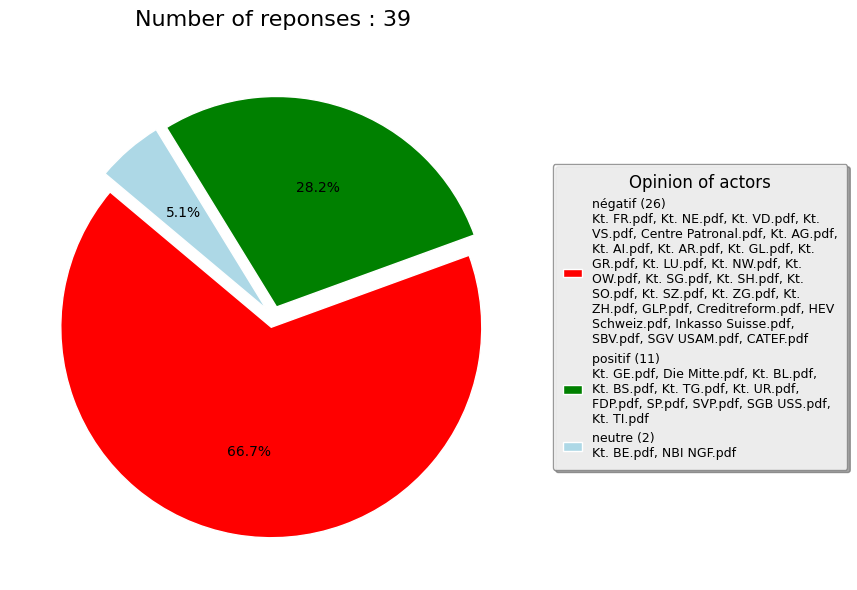

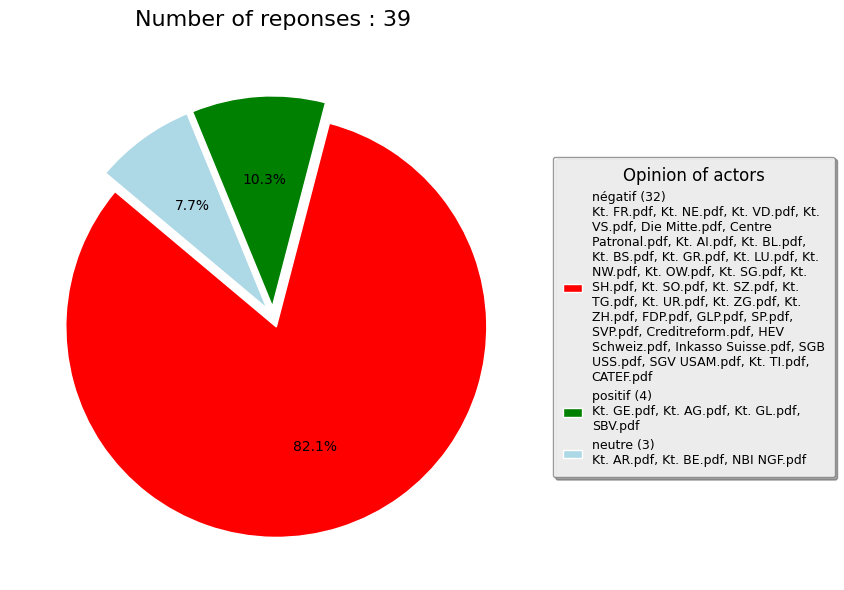

✅ Graphiques enregistrés dans : /content/drive/MyDrive/consu_interest/Graph


In [ ]:
output_dir = '/content/drive/MyDrive/consu_interest/Graph'
os.makedirs(output_dir, exist_ok=True)

for volet in ['volet1_fr', 'volet2_fr']:
    # 2) Comptage et listes d’acteurs
    counts = df[volet].dropna().value_counts()
    actors_by_cat = df.dropna(subset=[volet]).groupby(volet)['filename'].apply(list).to_dict()
    total_responses = counts.sum()

    # 3) Création de la figure
    fig, ax = plt.subplots(figsize=(8, 6))

    # 4) Couleurs et explosion
    color_map = {'négatif': 'red', 'positif': 'green', 'neutre': 'lightblue'}
    colors = [color_map.get(cat, 'gray') for cat in counts.index]
    explode = [0.05] * len(counts)

    # 5) Tracé du camembert
    wedges, texts, autotexts = ax.pie(
        counts,
        labels=None,
        autopct='%1.1f%%',
        pctdistance=0.6,
        startangle=140,
        explode=explode,
        wedgeprops={'linewidth': 1, 'edgecolor': 'white'},
        colors=colors
    )
    ax.set_aspect('equal', 'box')
    ax.set_title(f"Number of reponses : {total_responses}", fontsize=16, pad=20)

    # 6) Préparation des labels de légende
    legend_labels = []
    for cat, n in counts.items():
        detail = ", ".join(actors_by_cat.get(cat, []))
        wrapped = textwrap.fill(detail, width=40)
        legend_labels.append(f"{cat} ({n})\n{wrapped}")

    # 7) Légende à droite
    ax.legend(
        wedges,
        legend_labels,
        title="Opinion of actors",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=9,
        title_fontsize=12,
        frameon=True,
        shadow=True,
        facecolor='white',
        framealpha=0.8,
        edgecolor='gray',
        handlelength=1.5,
        borderpad=0.8
    )

    plt.tight_layout()

    # 8) Sauvegarde et affichage
    out_path = os.path.join(output_dir, f"repartition_{volet}.pdf")
    fig.savefig(out_path, bbox_inches='tight')
    plt.show()
    plt.close()

print(f"✅ Graphiques enregistrés dans : {output_dir}")


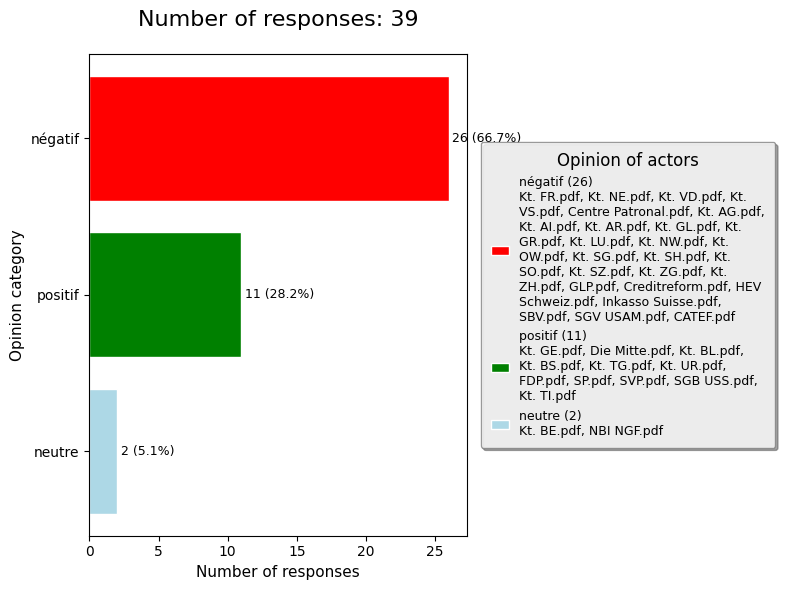

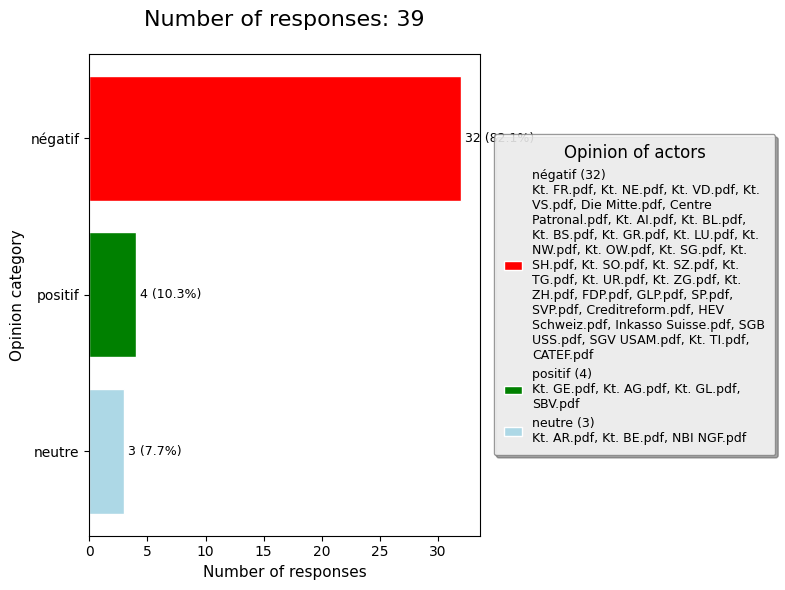

✅ Graphiques enregistrés dans : /content/drive/MyDrive/consu_interest/Graph


In [ ]:
for volet in ['volet1_fr', 'volet2_fr']:
    # 2) Comptage et listes d’acteurs
    counts = df[volet].dropna().value_counts()
    actors_by_cat = (
        df.dropna(subset=[volet])
          .groupby(volet)['filename']
          .apply(list)
          .to_dict()
    )
    total_responses = counts.sum()

    # 3) Création de la figure
    fig, ax = plt.subplots(figsize=(8, 6))

    # 4) Couleurs (réutilise la même palette que le camembert)
    color_map = {'négatif': 'red', 'positif': 'green', 'neutre': 'lightblue'}
    colors = [color_map.get(cat, 'gray') for cat in counts.index]

    # 5) Tracé du bar chart horizontal
    bars = ax.barh(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1)

    ax.set_xlabel("Number of responses", fontsize=11)
    ax.set_ylabel("Opinion category", fontsize=11)
    ax.set_title(f"Number of responses: {total_responses}", fontsize=16, pad=20)

    # Mettre la catégorie la plus fréquente en haut
    ax.invert_yaxis()

    # Afficher compte + pourcentage au bout des barres
    vals = counts.values
    pcts = (vals / total_responses) * 100
    xpad = max(vals) * 0.01 if len(vals) else 0.5
    for i, (v, p) in enumerate(zip(vals, pcts)):
        ax.text(v + xpad, i, f"{v} ({p:.1f}%)", va='center', fontsize=9)

    # 6) Préparation des labels de légende (catégorie + acteurs)
    legend_labels = []
    for cat, n in counts.items():
        detail = ", ".join(actors_by_cat.get(cat, []))
        wrapped = textwrap.fill(detail, width=40) if detail else "No actors listed"
        legend_labels.append(f"{cat} ({n})\n{wrapped}")

    # 7) Légende à droite (on utilise les barres comme handles)
    ax.legend(
        bars,
        legend_labels,
        title="Opinion of actors",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=9,
        title_fontsize=12,
        frameon=True,
        shadow=True,
        facecolor='white',
        framealpha=0.8,
        edgecolor='gray',
        handlelength=1.5,
        borderpad=0.8
    )

    plt.tight_layout()

    # 8) Sauvegarde et affichage
    out_path = os.path.join(output_dir, f"repartition_{volet}.pdf")
    fig.savefig(out_path, bbox_inches='tight')
    plt.show()
    plt.close()

print(f"✅ Graphiques enregistrés dans : {output_dir}")

/tmp/ipython-input-3959477451.py:23: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


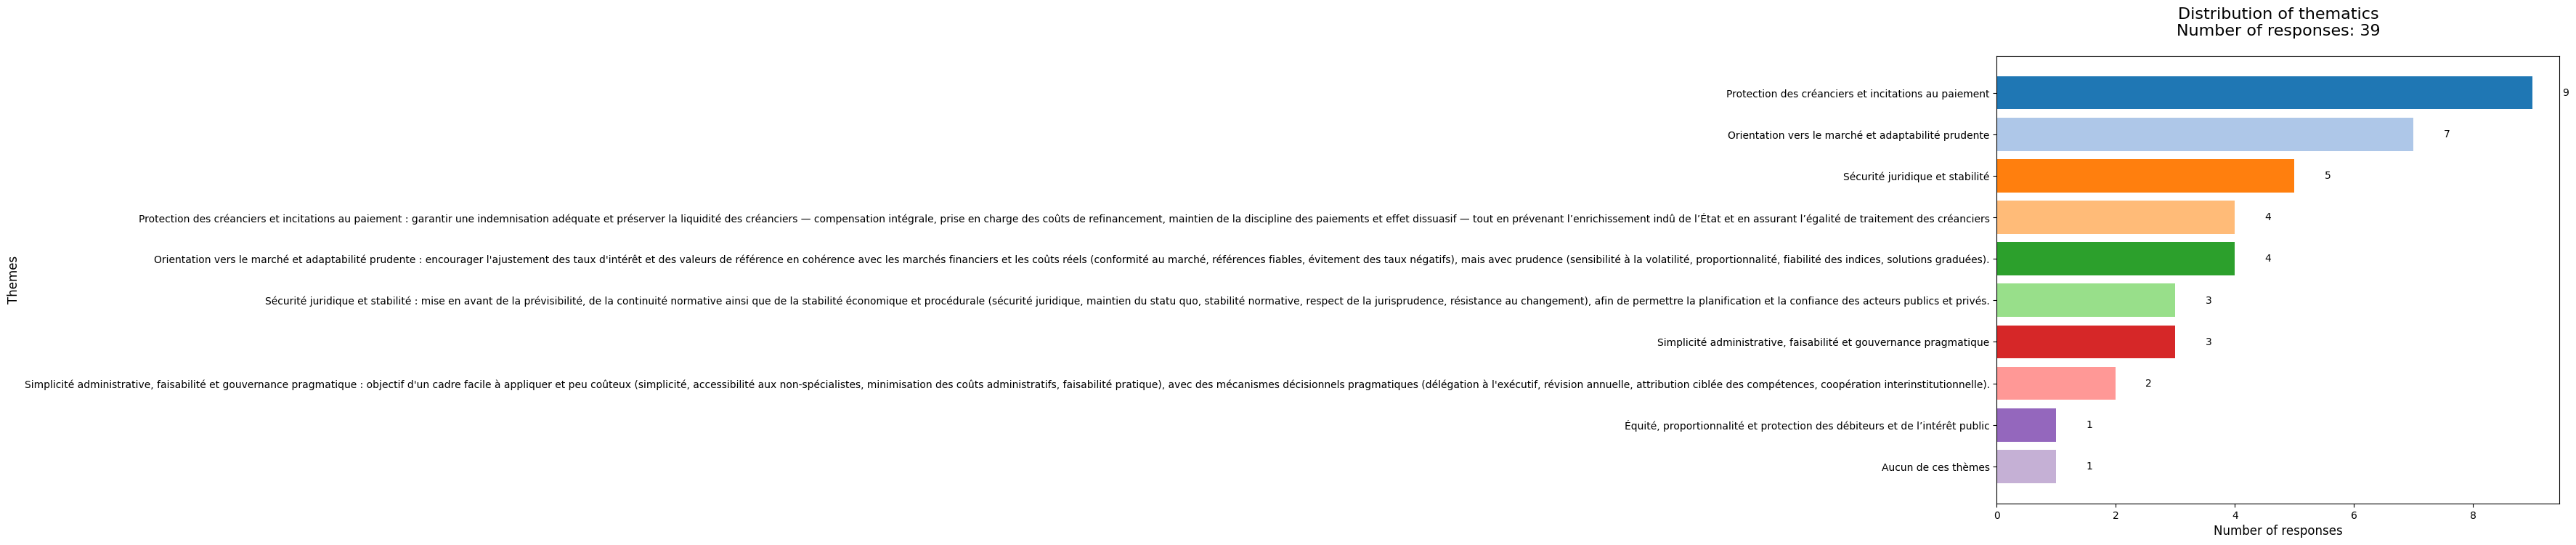

/tmp/ipython-input-3959477451.py:83: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


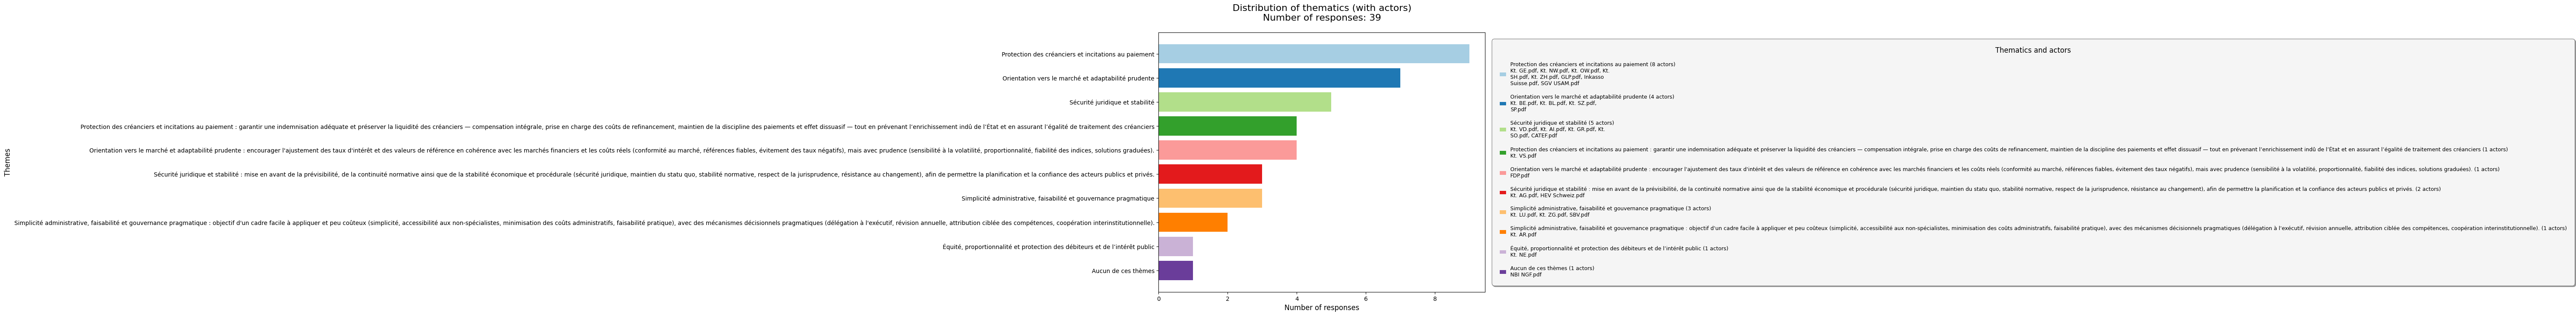

✅ Graphique enregistré dans : ./graphs/distribution_cleaned_themes_actors.pdf


In [ ]:
# --- Graph Styling (Themes Only) ---
fig, ax = plt.subplots(figsize=(10, 8))

# Create horizontal bar chart
ax.barh(cleaned_counts.index, cleaned_counts.values, color=plt.cm.tab20.colors)

# Add labels and title
ax.set_xlabel("Number of responses", fontsize=12)
ax.set_ylabel("Themes", fontsize=12)
ax.set_title(
    f"Distribution of thematics\nNumber of responses: {cleaned_counts.sum()}",
    fontsize=16,
    pad=20
)

# Invert y-axis so most frequent themes appear on top
ax.invert_yaxis()

# Add counts on bars
for i, (value, name) in enumerate(zip(cleaned_counts.values, cleaned_counts.index)):
    ax.text(value + 0.5, i, str(value), va='center', fontsize=10)

plt.tight_layout()
plt.show()

# Ensure cleaned_theme column exists and fill unmapped themes
if 'cleaned_theme' not in df.columns:
    df['cleaned_theme'] = df[theme_col]

# Fill missing values in cleaned_theme with original themes
df['cleaned_theme'] = df['cleaned_theme'].fillna(df[theme_col])


# --- Second Graph (Themes with Actors, with Legend) ---
actors_by_cat = df.groupby('cleaned_theme')['filename'].apply(list)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(cleaned_counts.index, cleaned_counts.values, color=plt.cm.Paired.colors)

ax.set_xlabel("Number of responses", fontsize=12)
ax.set_ylabel("Themes", fontsize=12)
ax.set_title(
    f"Distribution of thematics (with actors)\nNumber of responses: {cleaned_counts.sum()}",
    fontsize=16,
    pad=20
)

# Invert y-axis for readability
ax.invert_yaxis()

# Prepare legend labels with actor details
def wrap_label(cat):
    acteurs = actors_by_cat.get(cat, [])
    acteurs_str = ", ".join(acteurs)
    # Wrap text every ~40 chars for readability
    wrapped = "\n".join(textwrap.wrap(acteurs_str, width=40)) if acteurs_str else "No actors listed"
    return f"{cat} ({len(acteurs)} actors)\n{wrapped}"

legend_labels = [wrap_label(cat) for cat in cleaned_counts.index]

# Add legend on the right
legend = ax.legend(
    bars,
    legend_labels,
    title="Thematics and actors",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9,
    title_fontsize=12,
    ncol=1,
    frameon=True,
    shadow=True,
    facecolor='white',
    framealpha=0.9,
    edgecolor='gray',
    borderpad=1,
    handlelength=1.2,
    handletextpad=0.8,
    labelspacing=1.5
)
legend.get_frame().set_boxstyle('round,pad=0.5')

plt.tight_layout()
plt.show()

# Save the figure
output_dir = './graphs'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "distribution_cleaned_themes_actors.pdf")
fig.savefig(output_path, bbox_inches="tight")
plt.close()

print(f"✅ Graphique enregistré dans : {output_path}")



Maintenant nous essayons de develloper un prompt qui permet de voir les propositions de modification qui sont proposées par les differentes parties prenantes

In [ ]:

import logging

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)
logger = logging.getLogger(__name__)

# --- Prompt templates ---
templates = {
    "FR": {
        "Amendement": (
            "Tu es un haut-fonctionnaire mandaté pour produire un rapport sur la réforme du "
            "du taux de l’intérêt moratoire.\n"
            "Tu recevras **un avis de partie prenante à la fois**. Pour chaque avis, fais :\n"
            "1. **Extrais uniquement les propositions de modification** sous forme de liste à puces.\n"
            "2. Pour chaque proposition : reformulation concise, catégorie, référence précise.\n"
            "3. **Pas d'autre commentaire**.\n\n"
            "**Texte :** {texte}"
        )
    },
    "DE": {
        "Amendement": (
            """\
Du bist ein hoher Beamter, der beauftragt wurde, einen Bericht über die Reform des Verzugszinssatzes zu erstellen.
Du wirst **jeweils nur eine Stellungnahme von Stakeholdern** erhalten. Für jede Stellungnahme:

1. **Extrahiere ausschließlich die Änderungsvorschläge** und gib sie als Aufzählungsliste aus.
2. Für jeden Vorschlag:
   - prägnante Umformulierung
   - Kategorie
   - genaue Referenz
3. **Keinen weiteren Kommentar**.

**Text:** {texte}"""
        )
    },
    "IT": {
        "Amendement": (
            """\
Sei un alto funzionario incaricato di redigere un rapporto sulla riforma del tasso di interesse moratorio.
Riceverai **un parere di stakeholder alla volta**. Per ciascun parere:

1. **Estrai esclusivamente le proposte di modifica** e riportale come elenco puntato.
2. Per ogni proposta:
   - riformulazione concisa
   - categoria
   - riferimento preciso
3. **Nessun altro commento**.

**Testo:** {texte}"""
        )
    },
}

# --- Load existing results if any ---
if output_excel.exists():
    try:
        df_existing = pd.read_excel(output_excel)
        logger.info("Loaded existing results from %s", output_excel)
    except Exception as e:
        logger.error("Failed to read existing Excel: %s", e)
        df_existing = pd.DataFrame(columns=["filename", "Amendement"])
else:
    df_existing = pd.DataFrame(columns=["filename", "Amendement"])

def extract_text_from_pdf(path: Path) -> str:
    """Lit et concatène le texte de chaque page du PDF."""
    try:
        reader = PdfReader(str(path))
        texts = [page.extract_text() or "" for page in reader.pages]
        full = "\n".join(texts)
        return full
    except Exception as e:
        logger.warning("Erreur lors de l'extraction de texte pour %s: %s", path, e)
        return ""

print("\n=== PROMPT ENVOYÉ ===")
print(prompt)
def call_llm(prompt: str) -> str:
    """Appel à l'LLM OpenAI et retourne la sortie."""
    try:
        response_obj = client.chat.completions.create(
            model=model_name,
            messages=[{"role": "user", "content": prompt}],
            temperature=TEMPERATURE   # <-- your global temperature
        )
        result = response_obj.choices[0].message.content.strip()
        print("=== RÉPONSE DU MODÈLE ===")
        print(result)
        return result

    except Exception as e:
        logger.error("LLM call failed: %s", e)
        return ""


amend_dict = {}
for lang, folder in roots.items():
    if lang not in templates:
        logger.warning("No template for language %s, skipping", lang)
        continue
    tpl = templates[lang]["Amendement"]
    for pdf_path in folder.rglob("*.pdf"):
        logger.info("Processing %s", pdf_path.name)
        text = extract_text_from_pdf(pdf_path)
        if not text.strip():
            logger.warning("No text extracted for %s, skipping LLM", pdf_path.name)
            amend_dict[pdf_path.name] = ""
            continue
        prompt = tpl.format(texte=full_text)
        result = call_llm(prompt)
        amend_dict[pdf_path.name] = result

if not df_existing.empty:
    df_existing.set_index("filename", inplace=True)
    df_existing["Amendement"] = pd.Series(amend_dict)
    df_final = df_existing.reset_index()
else:
    df_final = pd.DataFrame(
        [{"filename": fname, "Amendement": a} for fname, a in amend_dict.items()]
    )

try:
    df_final.to_excel(output_excel, index=False)
    logger.info("Results saved to %s", output_excel)
except Exception as e:
    logger.error("Failed to write Excel: %s", e)

print(df_final.head())



=== PROMPT ENVOYÉ ===
Sei un alto funzionario incaricato di redigere un rapporto di consultazione su una riforma del tasso di interesse moratorio.
Per ciascun parere di un attore su due ambiti, indica se il parere è positivo, negativo o neutro.
Rispondi *ESCLUSIVAMENTE* con una sola parola tra: “positivo”, “neutro” o “negativo”.
Usa questo formato di risposta: "ambito1": "positivo|negativo|neutro", "ambito2": "positivo|negativo|neutro"

Ambiti:
1) Un tasso di interesse variabile, fissato ogni anno dal Consiglio federale sulla base del SARON maggiorato di 2 punti percentuali.
2) Mantenere un tasso di interesse fisso ma ridurlo del 3% rispetto all'attuale.

Parere da analizzare:
Cariera  ticinese  Via Trevano  39 Fax  091  972  91 73
dei'economia  fondiaria  CP 4137  info@catef.ch
6904  Lugano  www.catef.ch
Tel.  091  972  91 71 CHE-108.159.805  IVA
ZZ@bj.admin.ch
Lodevole  Commissione  degli  affari
giuridici  del Consiglio  Nazionale
3003  Berna
a.c.a.  On.  Vincent  Maitre
Lugano,  2

Pour finaliser notre analyse nous allons demander un avis général a notre modele sur l'ensemble du processus de consultation en utilisant les résumés produits.

In [ ]:
#Nous allons pour l'instant traduire les résumés en francais pour assurer la coherence du texte pour le modele.



# 1) Chemins
base_dir     = Path('/content/drive/MyDrive/consu_interest')
input_excel  = base_dir / "openai_outputs_with_thematics.xlsx"
output_excel = base_dir / "openai_outputs_with_thematics.xlsx"

# 3) Template de traduction
translate_template = (
    "Veuillez traduire en français ce court texte en veillant à ce que le contenu soit clair et précis :\n\n"
    "{summary}\n\n"
    "**Réponds** sans en-tête, sans guillemets, sans autre texte."
    "texte en français :"
)


# 4) Fonction de traduction
def translate_thematics(text):
    if not text.strip():
        return ""  # rien à traduire
    prompt = translate_template.format(summary=text)
    # Affichage du prompt
    print("\n=== PROMPT ENVOYÉ ===")
    print(prompt)

    # --- OPENAI CALL (replacing ollama) ---
    try:
        response_obj = client.chat.completions.create(
            model=model_name,
            messages=[{"role": "user", "content": prompt}],
            temperature=TEMPERATURE      # ← global variable you set at the top
        )
        response = response_obj.choices[0].message.content.strip()

    except Exception as e:
        print(f"⚠️ Échec pour «{text[:30]}…»\n{e}")
        return ""
    # --------------------------------------

    print("=== RÉPONSE DU MODÈLE ===")
    print(response)

    return response

# 5) Appliquer la traduction
df['summary_fr'] = df['summary'].astype(str).apply(translate_thematics)

# 6) Sauvegarder
df.to_excel(output_excel, index=False)
print("✅ Colonnes traduites ajoutées et fichier enregistré dans :", output_excel)


=== PROMPT ENVOYÉ ===
Veuillez traduire en français ce court texte en veillant à ce que le contenu soit clair et précis :

Le Conseil d’État de Fribourg, consulté sur la proposition de réviser l’art. 104 al. 1 CO afin d’aligner le taux de l’intérêt moratoire sur les taux du marché, confirme d’emblée que le taux légal actuel de 5 % ne reflète plus la réalité des marchés. Il refuse cependant la modification proposée par la Commission des affaires juridiques.

Il rappelle la nature et la finalité de l’intérêt moratoire : indemniser le créancier en cas de demeure du débiteur et surtout inciter à la ponctualité des paiements, contrairement à un intérêt transactionnel ou de refinancement. Sur le plan économique, les retards de paiement engendrent des coûts importants pour les entreprises et peuvent freiner la création d’emplois.

Au regard de cet objectif, le Conseil d’État juge inappropriée une baisse marquée du taux (par exemple à 3 %) car elle risquerait d’aggraver les délais de paiement

In [ ]:
import subprocess, os

# --- Chargement et nettoyage
df = pd.read_excel(input_excel, sheet_name=0, engine='openpyxl')
df.columns = df.columns.str.strip()

col_name = 'summary_fr'
if col_name not in df.columns:
    raise KeyError(f"La colonne '{col_name}' n’existe pas.")

texts = (
    df[col_name]
    .dropna()
    .astype(str)
    .str.strip()
    .loc[lambda s: s != ""]
    .tolist()
)
if not texts:
    raise ValueError(f"Aucun résumé trouvé dans '{col_name}'")

numbered = "\n".join(f"{i+1}. {t}" for i, t in enumerate(texts, 1))

# --- Construction du prompt
prompt = f"""\
Tu es un haut fonctionnaire chargé de produire un rapport synthétique sur une consultation concernant une réforme du taux de l’intérêt moratoire.

Tu vas recevoir ci-dessous une liste numérotée contenant les résumés individuels des avis exprimés par chacune des parties prenantes concernant le sujet de consultation suivant :
« {col_name} »

{numbered}

Sur la base de ces résumés individuels, ta tâche consiste à produire une synthèse très succincte de l'opinion générale des parties prenantes sur le sujet, en suivant ces consignes strictes :

    1) Identifie une unique catégorie exprimant la tendance générale dominante parmi les avis (ex. consensus positif, consensus négatif, division, réserve générale, soutien conditionnel, etc.).
    2) Rédige une description concise explicitant clairement et précisément cette position générale, en mettant en évidence les points majeurs d'accord ou de désaccord mentionnés fréquemment par les parties prenantes.

Réponds sans en-tête, sans guillemets.
"""
print("=== PROMPT ENVOYÉ ===\n", prompt)

# --- OPENAI CALL replacing ollama ---
try:
    response_obj = client.chat.completions.create(
        model=model_name,
        messages=[{"role": "user", "content": prompt}],
        temperature=TEMPERATURE      # ← global variable you defined
    )
    response = response_obj.choices[0].message.content.strip()

except Exception as e:
    raise RuntimeError(f"OpenAI erreur :\n{e}")
# ------------------------------------

print("=== RÉPONSE DU MODÈLE ===\n", response)


if 'Global_Summary' in df.columns:
    df = df.drop(columns=['Global_Summary'])

insert_at = df.columns.get_loc(col_name) + 1
df.insert(insert_at, 'Global_Summary', "")
df.iat[0, insert_at] = response

df.to_excel(input_excel, index=False)
print("✅ Colonne 'Global_Summary' ajoutée, réponse insérée en ligne 1.")


=== PROMPT ENVOYÉ ===
 Tu es un haut fonctionnaire chargé de produire un rapport synthétique sur une consultation concernant une réforme du taux de l’intérêt moratoire.

Tu vas recevoir ci-dessous une liste numérotée contenant les résumés individuels des avis exprimés par chacune des parties prenantes concernant le sujet de consultation suivant :
« summary_fr »

2. Le Conseil d’État de Fribourg, consulté sur la proposition de réviser l’article 104, alinéa 1 CO afin d’aligner le taux de l’intérêt moratoire sur les taux du marché, constate d’emblée que le taux légal actuel de 5 % ne reflète plus la réalité des marchés. Il refuse toutefois la modification proposée par la Commission des affaires juridiques.

Il rappelle que l’intérêt moratoire a pour objet d’indemniser le créancier en cas de demeure du débiteur et, surtout, d’inciter à la ponctualité des paiements, contrairement aux intérêts transactionnels ou de refinancement. Sur le plan économique, les retards de paiement entraînent des

In [ ]:

col_name = 'summary_fr'
if col_name not in df.columns:
    raise KeyError(f"La colonne '{col_name}' n’existe pas.")

texts = (
    df[col_name]
    .dropna()
    .astype(str)
    .str.strip()
    .loc[lambda s: s != ""]
    .tolist()
)
if not texts:
    raise ValueError(f"Aucun résumé trouvé dans '{col_name}'")

numbered = "\n".join(f"{i+1}. {t}" for i, t in enumerate(texts, 1))

# --- Construction du prompt
prompt = f"""\
Tu es un haut fonctionnaire chargé de produire un rapport synthétique sur une consultation concernant une réforme du taux de l’intérêt moratoire

Tu vas recevoir ci-dessous une liste numérotée contenant les résumés individuels des avis exprimés par chacune des parties prenantes concernant le sujet de consultation suivant :
« {col_name} »

{numbered}

Sur la base de ces résumés individuels, ta tâche consiste à produire une synthèse des justifications principales des parties prenantes sur le sujet, il faut que tu donnes les grandes raisons pourquoi les acteurs sont contre ou pour la réforme , formule ta réponse sous la forme d'une liste a puce.

Réponds sans en-tête, sans guillemets.
"""
print("=== PROMPT ENVOYÉ ===\n", prompt)


# --- OPENAI CALL replacing Ollama ---
try:
    response_obj = client.chat.completions.create(
        model=model_name,
        messages=[{"role": "user", "content": prompt}],
        temperature=TEMPERATURE       # <--- your global temperature variable
    )
    response = response_obj.choices[0].message.content.strip()

except Exception as e:
    raise RuntimeError(f"OpenAI erreur :\n{e}")
# ------------------------------------

print("=== RÉPONSE DU MODÈLE ===\n", response)


if 'Position_Summary' in df.columns:
    df = df.drop(columns=['Position_Summary'])

insert_at = df.columns.get_loc(col_name) + 1
df.insert(insert_at, 'Position_Summary', "")
df.iat[0, insert_at] = response

df.to_excel(input_excel, index=False)
print("✅ Colonne 'Position_Summary' ajoutée, réponse insérée en ligne 1.")


=== PROMPT ENVOYÉ ===
 Tu es un haut fonctionnaire chargé de produire un rapport synthétique sur une consultation concernant une réforme du taux de l’intérêt moratoire

Tu vas recevoir ci-dessous une liste numérotée contenant les résumés individuels des avis exprimés par chacune des parties prenantes concernant le sujet de consultation suivant :
« summary_fr »

2. Le Conseil d’État de Fribourg, consulté sur la proposition de réviser l’article 104, alinéa 1 CO afin d’aligner le taux de l’intérêt moratoire sur les taux du marché, constate d’emblée que le taux légal actuel de 5 % ne reflète plus la réalité des marchés. Il refuse toutefois la modification proposée par la Commission des affaires juridiques.

Il rappelle que l’intérêt moratoire a pour objet d’indemniser le créancier en cas de demeure du débiteur et, surtout, d’inciter à la ponctualité des paiements, contrairement aux intérêts transactionnels ou de refinancement. Sur le plan économique, les retards de paiement entraînent des 